## Predicción de User Rating para animes - LETICIA MARTICORENA

El objetivo principal es desarrollar un modelo que pueda predecir la calificación de los usuarios (User Rating) para diferentes *animes* basándose en las características disponibles. Esta información podría ser utilizada por una plataforma de streaming para mejorar su sistema de recomendaciones y ayudar a los usuarios a descubrir contenido relevante. 
Se usará el archivo de datos **imdb_anime.csv**, que contiene las siguientes columnas:

● Title: Nombre de la animación  
● Genre: Género(s) bajo el cual cae la animación, por ejemplo, Acción, Aventura, etc.  
● User Rating: IMDb calificación de usuarios sobre 10.  
● Number of Votes: Total de usuarios de IMDb que han calificado la animación.  
● Runtime: Duración de la animación en minutos.  
● Year: Año en que se estrenó o comenzó a emitirse la animación.  
● Summary: Un resumen breve o completo de la trama de la animación. Resúmenes 
completos se obtienen cuando están disponibles.  
● Stars: Lista de actores principales o actores de voz involucrados en la animación.  
● Certificate: Certificación de la animación, por ejemplo, PG, PG-13, etc.  
● Metascore: Calificación de Metascore, si disponible, que es una puntuación agregada 
de varios críticos.  
● Gross: Ganancias brutas o recaudación en taquilla de la animación.  
● Episode: Indicador binario si la lista es para un episodio de una serie (1 para sí, 0 
para no).  
● Episode Title: Título del episodio si la lista es para un episodio; de lo contrario, será 
None (Ninguno).

#### Carga y preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.stats import f_oneway

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cargar datos

df = pd.read_excel("imdb_anime.xlsx")
df.head()

,Title,Genre,User Rating,Number of Votes,Runtime,Year,Summary,Stars,Certificate,Metascore,Gross,Episode,Episode Title
0,One Piece,"Animation, Action, Adventure",8.9,187689,24 min,(1999– ),Follows the adventures of Monkey D. Luffy and ...,"Mayumi Tanaka,Laurent Vernin,Akemi Okamura,Ton...",TV-14,NaN,187689,0,NaN
1,Teenage Mutant Ninja Turtles: Mutant Mayhem,"Animation, Action, Adventure",7.4,28895,99 min,-2023,The film follows the Turtle brothers as they w...,NaN,PG,74,28895,0,NaN
2,The Super Mario Bros. Movie,"Animation, Adventure, Comedy",7.1,189108,92 min,-2023,A plumber named Mario travels through an under...,NaN,PG,46,189108,0,NaN
3,Attack on Titan,"Animation, Action, Adventure",9.1,434457,24 min,(2013–2023),After his hometown is destroyed and his mother...,"Josh Grelle,Bryce Papenbrook,Yûki Kaji,Yui Ish...",TV-MA,NaN,434457,0,NaN
4,Jujutsu Kaisen,"Animation, Action, Adventure",8.5,82909,24 min,(2020– ),A boy swallows a cursed talisman - the finger ...,"Junya Enoki,Yûichi Nakamura,Adam McArthur,Yuma...",TV-MA,NaN,82909,0,NaN


In [5]:
df.describe()

,Title,Genre,User Rating,Number of Votes,Runtime,Year,Summary,Stars,Certificate,Metascore,Gross,Episode,Episode Title
count,45717,45717,25009.0,25009,32549,45591,23547,13676,28694,341,25009,45717,34910
unique,9851,201,87.0,3033,196,740,22588,6460,33,60,3033,3,33779
top,Doraemon,"Animation, Action, Adventure",7.6,7,24 min,(1969– ),A young teen who surfs the skies with his ref ...,"Nobuyo Ôyama,Noriko Ohara,Michiko Nomura,Kazuy...",TV-14,74,7,1,Episode #1.4
freq,2758,13568,1270.0,567,9636,2399,25,765,10033,21,567,34909,12


In [7]:
df.dtypes

Title              object
Genre              object
User Rating        object
Number of Votes    object
Runtime            object
Year               object
Summary            object
Stars              object
Certificate        object
Metascore          object
Gross              object
Episode            object
Episode Title      object
dtype: object

## 1. Análisis de calidad de datos / Análisis exploratorio inicial 

In [10]:
# Detectando Valores Nulos (obtenido de clase tutoria)

# % de nulos por columna (ordenado de mayor a menor)
pct_nulos = (df.isna().mean() * 100).sort_values(ascending=False)

# Conteo de nulos por columna (mismo orden)
n_nulos = df.isna().sum().loc[pct_nulos.index]

# Tabla resumen
resumen_nulos = pd.DataFrame({
    "n_nulos": n_nulos,
    "pct_nulos": pct_nulos.round(2)
})

resumen_nulos.head(20)  # muestra las 20 columnas con más nulos

,n_nulos,pct_nulos
Metascore,45376,99.25
Stars,32041,70.09
Summary,22170,48.49
User Rating,20708,45.30
Number of Votes,20708,45.30
Gross,20708,45.30
Certificate,17023,37.24
Runtime,13168,28.80
Episode Title,10807,23.64
Year,126,0.28


In [12]:
# Cardinalidad: número de valores únicos por columna

valores_unicos = pd.DataFrame({
    "n_unicos": df.nunique(dropna=True),
    "pct_unicos": (df.nunique(dropna=True) / len(df) * 100).round(2)
}).sort_values("n_unicos", ascending=False)

valores_unicos

,n_unicos,pct_unicos
Episode Title,33779,73.89
Summary,22588,49.41
Title,9851,21.55
Stars,6460,14.13
Number of Votes,3033,6.63
Gross,3033,6.63
Year,740,1.62
Genre,201,0.44
Runtime,196,0.43
User Rating,87,0.19


En resumen, eliminación de variables:
- Se eliminarán variables con más del 70% de valores nulos: Metascore (99.25%) y Stars (70.09%)
- Se eliminarán variables con más del 40% de valores únicos: Episode Title (73.89%) y Summary (49.41%).
- Se eliminará la variable Title por tener un comportamiento de identificador.

#### Gráficos de variables

Nota: Se debieron hacer algunas transformaciones de los datos, solo para efectos del EDA, ya que dada su naturaleza object, los gráficos de distribución eran elegibles.

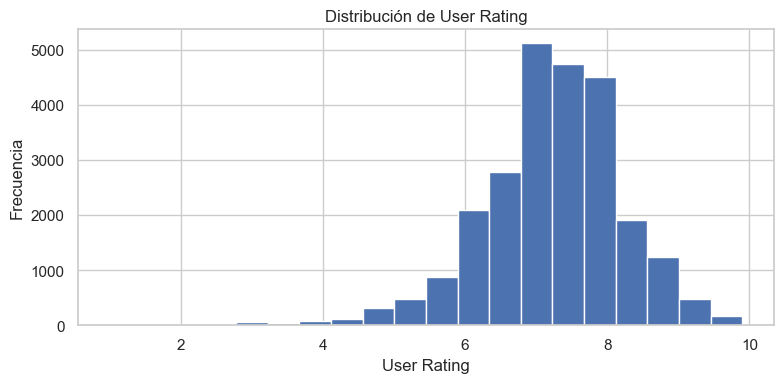

In [18]:
# 'User Rating' 

user_rating_num = pd.to_numeric(df["User Rating"], errors="coerce")

plt.figure(figsize=(8, 4))
plt.hist(user_rating_num, bins=20)
plt.title("Distribución de User Rating")
plt.xlabel("User Rating")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

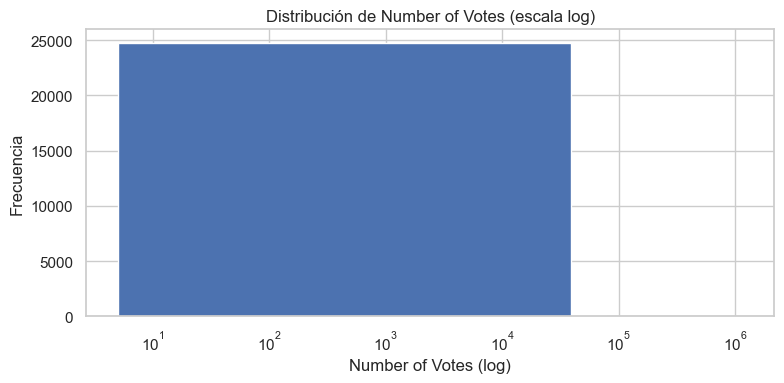

In [20]:
# 'Number of Votes'

votes_num = pd.to_numeric(df["Number of Votes"], errors="coerce")

plt.figure(figsize=(8, 4))
plt.hist(votes_num, bins=30)
plt.xscale("log")  # La distribución es asimétrica a la derecha (muchos valores pequeños)
plt.title("Distribución de Number of Votes (escala log)")
plt.xlabel("Number of Votes (log)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

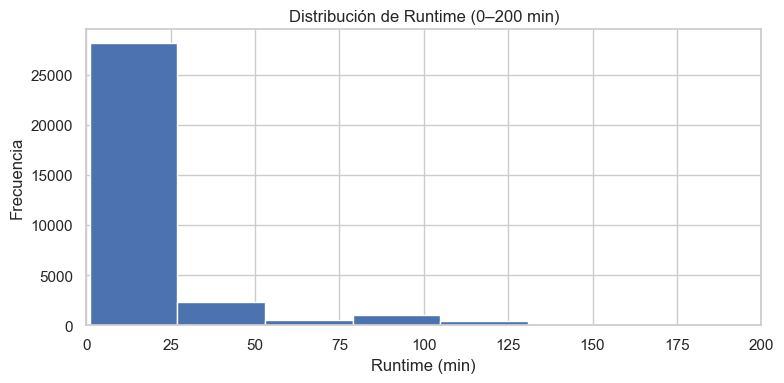

In [22]:
# HISTOGRAMAS (Variables numéricas)

# 'Runtime'

runtime_num = (
    df["Runtime"]
    .str.extract(r"(\d+)")
    .astype(float)
)

plt.figure(figsize=(8, 4))
plt.hist(runtime_num, bins=30)
plt.xlim(0, 200)   # rango informativo
plt.title("Distribución de Runtime (0–200 min)")
plt.xlabel("Runtime (min)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

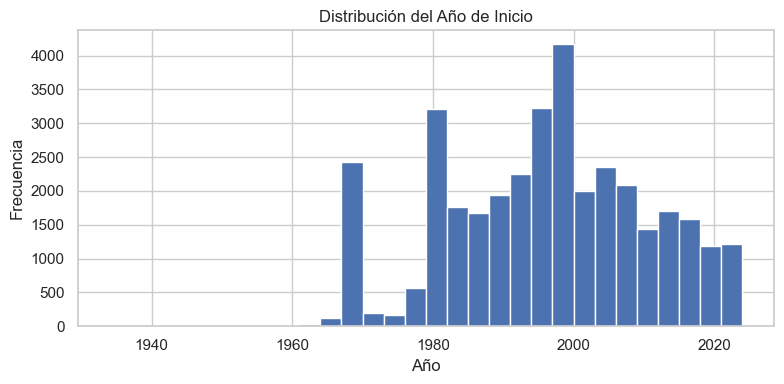

In [24]:
# 'Year'

year_start = (
    df["Year"]
    .str.extract(r"(\d{4})")
    .astype(float)
)

plt.figure(figsize=(8, 4))
plt.hist(year_start, bins=30)
plt.title("Distribución del Año de Inicio")
plt.xlabel("Año")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

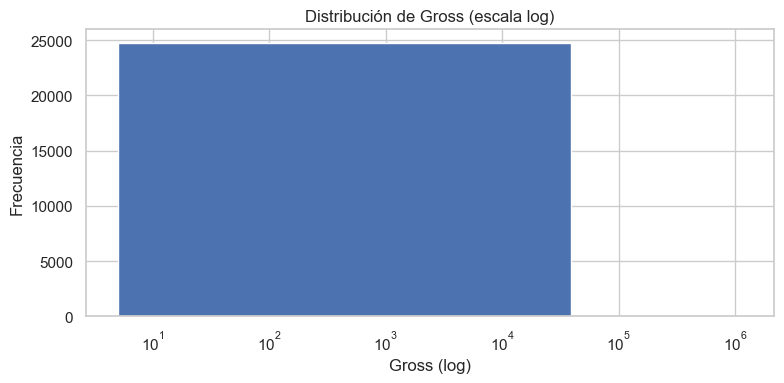

In [26]:
# 'Gross'

gross_num = pd.to_numeric(df["Gross"], errors="coerce")

plt.figure(figsize=(8, 4))
plt.hist(gross_num, bins=30)
plt.xscale("log")   # La distribución es asimétrica a la derecha (muchos valores pequeños)
plt.title("Distribución de Gross (escala log)")
plt.xlabel("Gross (log)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

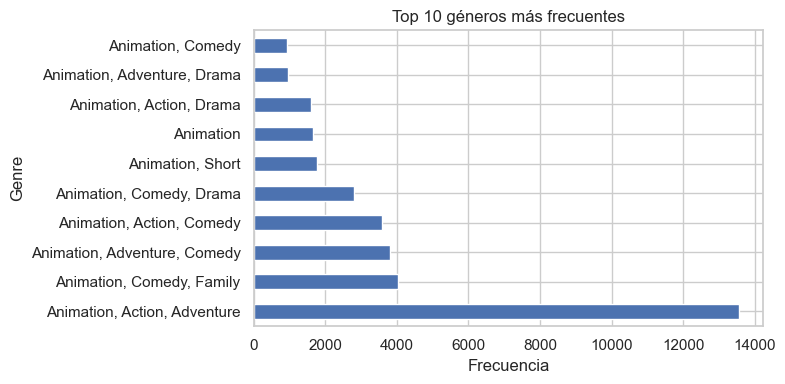

In [28]:
# GRAFICOS DE BARRA (Variables categóricas)

# 'Genre'

df["Genre"].value_counts().head(10).plot(
    kind="barh",
    figsize=(8, 4)
)

plt.title("Top 10 géneros más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

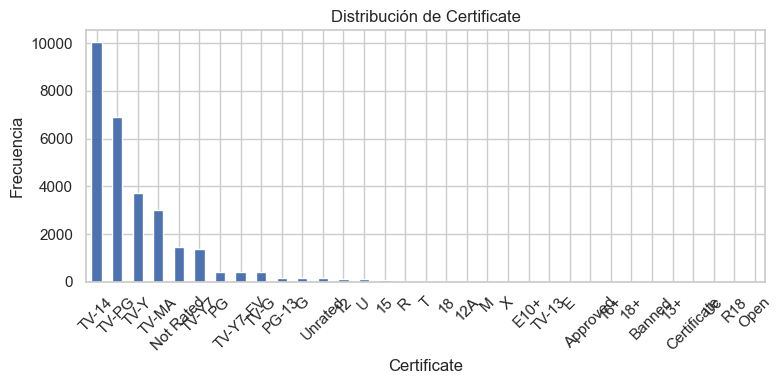

In [30]:
# 'Certificate'

df["Certificate"].value_counts().plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Distribución de Certificate")
plt.xlabel("Certificate")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

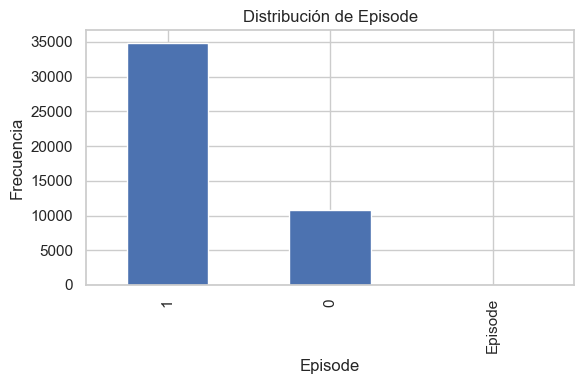

In [32]:
# 'Episode'

df["Episode"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Distribución de Episode")
plt.xlabel("Episode")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 2. Transformación Inicial de Datos

In [35]:
# Transformación de variables 'object' a tipo 'float'

df["user_rating"] = pd.to_numeric(df["User Rating"], errors="coerce")
df["num_votes"] = pd.to_numeric(df["Number of Votes"], errors="coerce")
df["gross"] = pd.to_numeric(df["Gross"], errors="coerce")

In [37]:
# Transformación de las variables con formato inadecuado, a numérica ('float')

df["runtime_min"] = (
    df["Runtime"]
    .str.extract(r"(\d+)")
    .astype(float)
)

df["year_start"] = (
    df["Year"]
    .str.extract(r"(\d{4})")
    .astype(float)
)

In [39]:
# Verificación

df[[
    "user_rating",
    "num_votes",
    "gross",
    "runtime_min",
    "year_start"
]].dtypes

user_rating    float64
num_votes      float64
gross          float64
runtime_min    float64
year_start     float64
dtype: object

Para las variables **Genre, Certificate y Episode** se harán transformaciones orientadas a la limpieza y estandarización del texto, con el objetivo de facilitar su posterior codificación:

- Genre: categorías desordenadas (ej. "action, adventure" y "adventure, action"), se transforma a lista de categorias
- Certificate: categorías desordenadas (ej. "tv-ma", "TV-MA", "Tv-Ma"), se normaliza
- Episode: los valores 0 y 1 se podrían tratar como texto genérico y perder la información, se transforma a tipo categórico

In [42]:
# 'Genre': Normalizar y convertir a lista

df["genre_list"] = df["Genre"].astype(str).str.strip().str.split(r"\s*,\s*")

In [44]:
# 'Certificate': Normalizar

df["certificate_clean"] = (
    df["Certificate"]
    .astype(str)
    .str.strip()
    .replace("nan", "UNKNOWN")
)

In [46]:
# 'Episode': transformar a categórica

df["episode_type"] = df["Episode"].astype("category")

In [48]:
# Creando un df con las columnas transformadas, y sin las columnas eliminadas

df2 = df[[
    "user_rating",
    "num_votes",
    "gross",
    "runtime_min",
    "year_start",
    "genre_list",
    "certificate_clean",
    "episode_type"
]].copy()

In [50]:
df2.head()

,user_rating,num_votes,gross,runtime_min,year_start,genre_list,certificate_clean,episode_type
0,8.9,187689.0,187689.0,24.0,1999.0,"[Animation, Action, Adventure]",TV-14,0
1,7.4,28895.0,28895.0,99.0,NaN,"[Animation, Action, Adventure]",PG,0
2,7.1,189108.0,189108.0,92.0,NaN,"[Animation, Adventure, Comedy]",PG,0
3,9.1,434457.0,434457.0,24.0,2013.0,"[Animation, Action, Adventure]",TV-MA,0
4,8.5,82909.0,82909.0,24.0,2020.0,"[Animation, Action, Adventure]",TV-MA,0


## 3. Revisión de outliers

In [53]:
# Columnas a revisar

num_cols = [
    "user_rating",
    "num_votes",
    "gross",
    "runtime_min",
    "year_start"
]

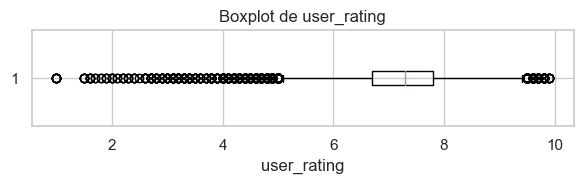

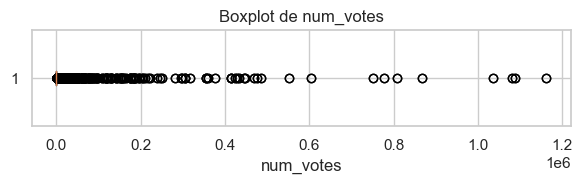

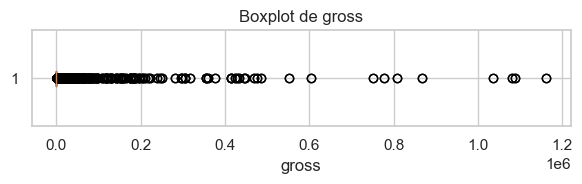

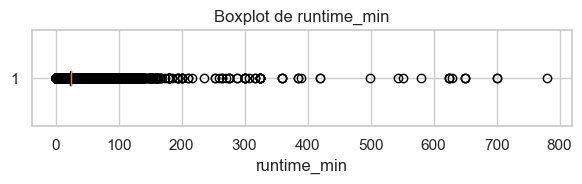

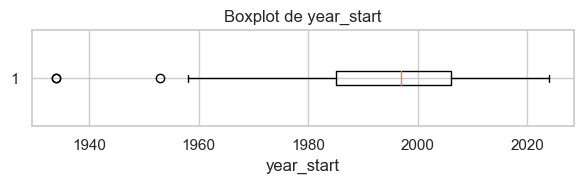

In [55]:
for col in num_cols:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df2[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

**Conclusión:** no se eliminarán valores de ninguna variable, ya que la gran mayoría parecen valores válidos, no errores. Para num_votes y gross quizás se requiera transformación log. 

### 4. Transformación de variables finales

#### Tratamiento de nulos

In [60]:
# Reemplazo de nulos x mediana

df4 = df2.copy()

num_cols = ["num_votes", "gross", "runtime_min", "year_start"]

for col in num_cols:
    df4[col] = df4[col].fillna(df4[col].median())

In [62]:
# Variable objetivo ('user_rating')

df4 = df4[df4["user_rating"].notna()] # Eliminación datos nulos

#### Transformaciones logarítmicas

In [65]:
# Para variables 'num_votes' y 'gross'

df4["log_num_votes"] = np.log1p(df4["num_votes"])  # log1p evita problemas con los ceros
df4["log_gross"] = np.log1p(df4["gross"])

#### Transformación de variables categóricas

In [68]:
# 'certificate' => One-Hot Encoding (variable nominal con baja cardinalidad)

df4 = pd.get_dummies(
    df4,
    columns=["certificate_clean"],
    prefix="cert",
    drop_first=True
)

In [70]:
# 'episode_type' => One-Hot Encoding 

df4 = pd.get_dummies(
    df4,
    columns=["episode_type"],
    prefix="episode",
    drop_first=True
)

In [72]:
# 'Genre' => Multi-label encoding

mlb = MultiLabelBinarizer()

genre_dummies = pd.DataFrame(
    mlb.fit_transform(df4["genre_list"]),
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=df4.index
)

df4 = pd.concat([df4, genre_dummies], axis=1)

In [74]:
df4.drop(columns=["genre_list"], inplace=True)  # Eliminar columna original

In [76]:
# Limpieza final de columnas (eliminar columnas que ya no se usarán)

df4.drop(
    columns=["num_votes", "gross"],
    inplace=True
)

In [82]:
# Revisión final de data

df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25008 entries, 0 to 45716
Data columns (total 61 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_rating        25008 non-null  float64
 1   runtime_min        25008 non-null  float64
 2   year_start         25008 non-null  float64
 3   log_num_votes      25008 non-null  float64
 4   log_gross          25008 non-null  float64
 5   cert_12A           25008 non-null  bool   
 6   cert_13+           25008 non-null  bool   
 7   cert_15            25008 non-null  bool   
 8   cert_16+           25008 non-null  bool   
 9   cert_18            25008 non-null  bool   
 10  cert_18+           25008 non-null  bool   
 11  cert_Approved      25008 non-null  bool   
 12  cert_Banned        25008 non-null  bool   
 13  cert_E             25008 non-null  bool   
 14  cert_E10+          25008 non-null  bool   
 15  cert_G             25008 non-null  bool   
 16  cert_M             25008 no

**Conclusión:** Se observa dataset correcto, sin nulos, transformaciones efectivas y dataset 100% numérico.

### 5. Análisis de Correlaciones

#### Correlación de Pearson

In [87]:
# Usaremos Pearson (numérica vs numérica), para user_rating con 1. runtime_min, 2. log_num_votes, 3. log_gross, 4. year_start

corr_pearson = df4[
    ["user_rating", "runtime_min", "log_num_votes", "log_gross", "year_start"]
].corr(method="pearson")

corr_pearson["user_rating"].sort_values(ascending=False)

user_rating      1.000000
log_num_votes    0.274853
log_gross        0.274853
year_start       0.132899
runtime_min     -0.043978
Name: user_rating, dtype: float64

- Las variables 'log_num_votes' y 'log_gross' tienes una relación positiva moderada con 'user_rating' (ambas miden popularidad / éxito), pero ambas podrían estar muy correlacionadas, por lo tanto quizás sean redundantes.
- 'year_start' tiene una relación débil, pero puede aportar algo de información.
- 'runtime_min' tiene una correlación muy baja, relación prácticamente inexistente.

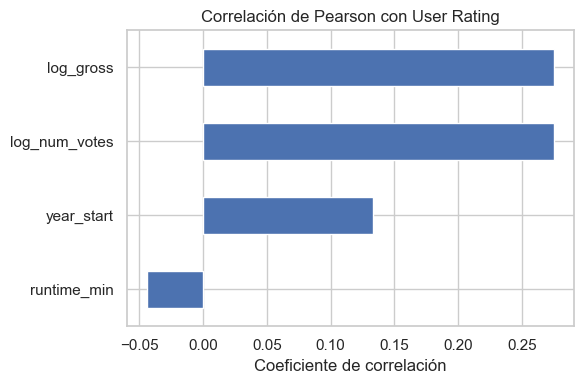

In [90]:
# Graficando

corr_target = (
    df4[["user_rating", "runtime_min", "log_num_votes", "log_gross", "year_start"]]
    .corr()["user_rating"]
    .drop("user_rating")
)

plt.figure(figsize=(6, 4))
corr_target.sort_values().plot(kind="barh")
plt.title("Correlación de Pearson con User Rating")
plt.xlabel("Coeficiente de correlación")
plt.tight_layout()
plt.show()

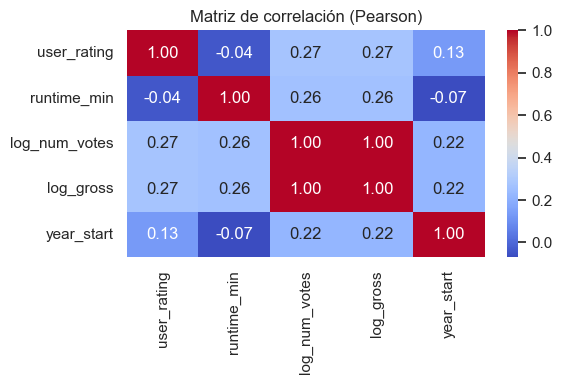

In [92]:
# Heatmap

import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(
    df4[["user_rating", "runtime_min", "log_num_votes", "log_gross", "year_start"]]
    .corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

#### ANOVA

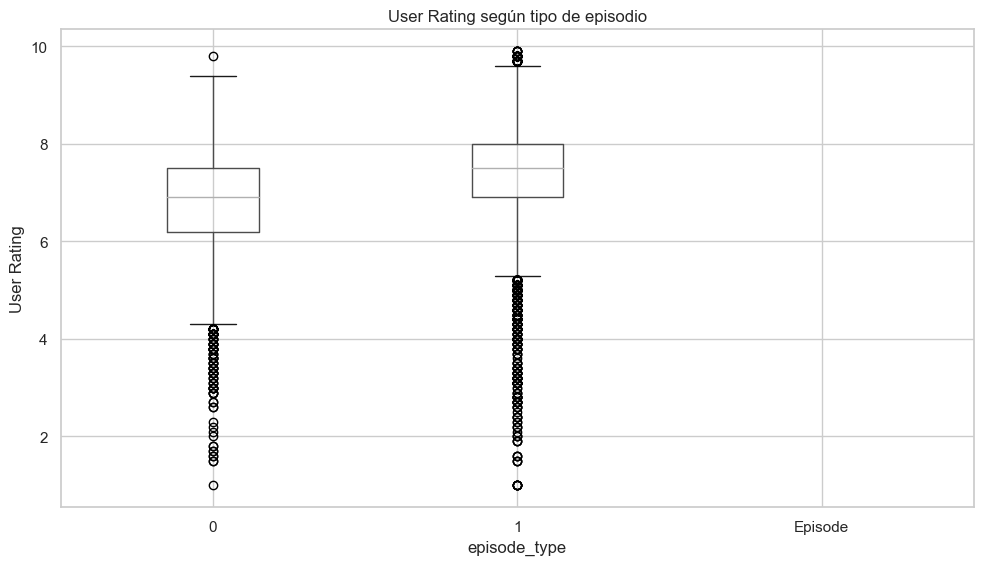

In [96]:
# Usaremos ANOVA (numérica vs categórica), para user_rating con 1. episode_type, 2. certificate, 3. genre
# Usaremos el dataset antes del encoding (df2)

df2.boxplot(column="user_rating", by="episode_type")
plt.title("User Rating según tipo de episodio")
plt.suptitle("")
plt.ylabel("User Rating")
plt.tight_layout()
plt.show()

Al analizar la variable 'episode_type' se observó que una de las categorías presenta un tamaño de muestra extremadamente reducido (n=1), lo que impide la aplicación del test ANOVA. Adicionalmente, se detectó una proporción relevante de valores faltantes en otras categorías. Por este motivo, el análisis se abordó mediante estadística descriptiva y visualizaciones, evitando el uso de un test paramétrico que no cumple sus supuestos en este contexto.

In [99]:
#'certificate'

df2["certificate_clean"].value_counts()

certificate_clean
UNKNOWN        17023
TV-14          10033
TV-PG           6904
TV-Y            3722
TV-MA           3014
Not Rated       1476
TV-Y7           1372
PG               425
TV-Y7-FV         411
TV-G             404
PG-13            173
G                142
Unrated          141
12               132
U                 99
15                94
R                 49
T                 23
18                15
12A               14
M                 12
X                  6
E10+               6
TV-13              4
E                  4
Approved           4
16+                3
18+                3
Banned             3
13+                2
Certificate        1
Uc                 1
R18                1
Open               1
Name: count, dtype: int64

In [101]:
# Se observan muchas categorías con n muy bajo (<50). ANOVA NO puede aplicarse a categorías con tamaños tan pequeños.
# Definiremos tamaños >=300

valid_certs = (
    df2["certificate_clean"]
    .value_counts()
    .loc[lambda x: x >= 300]
    .index
)

valid_certs

Index(['UNKNOWN', 'TV-14', 'TV-PG', 'TV-Y', 'TV-MA', 'Not Rated', 'TV-Y7',
       'PG', 'TV-Y7-FV', 'TV-G'],
      dtype='object', name='certificate_clean')

In [103]:
# Construcción de grupos

groups_cert = [
    df2[df2["certificate_clean"] == cert]["user_rating"].dropna()
    for cert in valid_certs
]

In [105]:
[(cert, g.shape[0], g.std()) for cert, g in zip(valid_certs, groups_cert)]

[('UNKNOWN', 5464, 1.1249594389809656),
 ('TV-14', 9362, 0.9573907314606971),
 ('TV-PG', 2918, 0.8451395538240757),
 ('TV-Y', 1090, 0.679123200715162),
 ('TV-MA', 2712, 0.9568438596254669),
 ('Not Rated', 1062, 0.7737378824074336),
 ('TV-Y7', 871, 0.8231031321264474),
 ('PG', 241, 0.9033438343109184),
 ('TV-Y7-FV', 340, 0.7623015098235275),
 ('TV-G', 236, 1.0803155467225507)]

In [107]:
# Aplicar ANOVA

f_stat, p_value = f_oneway(*groups_cert)
f_stat, p_value

(251.00799591286713, 0.0)

- F=251 muy alto => significa que hay gran variabilidad entre grupos respecto a la variabilidad interna
- p-value == 0.0 (< 0.05) es un resultado estadísticamente significativo
- Conclusión: Existen diferencias estadísticamente significativas en el 'User Rating' promedio según el Certificate

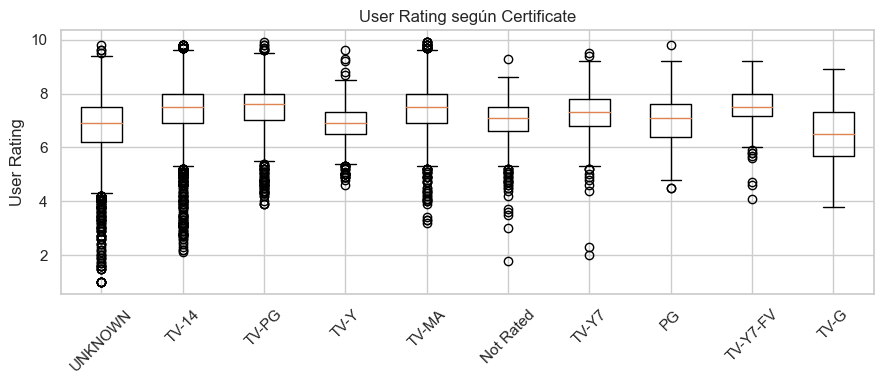

In [110]:
# Gráficos

plt.figure(figsize=(9, 4))
plt.boxplot(groups_cert, labels=valid_certs)
plt.ylabel("User Rating")
plt.title("User Rating según Certificate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Se observa TV-14, TV-PG, TV-MA, TV-Y7-FV con medianas más altas (>7.4)
- UNKNOWN y TV-G medianas más bajas y mayor dispersión
- Todas las categorías muestran outliers bajos (ratings muy bajos) y distribución relativamente similar

### 6. Función resumen del procesamiento 

In [114]:
# Función que preprocesa el dataset original y devuelve un df final

def preprocess_anime_dataset(df):

    df_proc = df.copy()

  # Variables numéricas
    df_proc["user_rating"] = pd.to_numeric(df_proc["User Rating"], errors="coerce")
    df_proc["num_votes"] = pd.to_numeric(df_proc["Number of Votes"], errors="coerce")
    df_proc["gross"] = pd.to_numeric(df_proc["Gross"], errors="coerce")
    df_proc["runtime_min"] = (
        df_proc["Runtime"].str.extract(r"(\d+)").astype(float))
    df_proc["year_start"] = (
        df_proc["Year"].str.extract(r"(\d{4})").astype(float))

  # Variables categóricas (pre-encoding)
    df_proc["genre_list"] = (
        df_proc["Genre"]
        .astype(str)
        .str.strip()
        .str.split(r"\s*,\s*"))
    df_proc["certificate_clean"] = (
        df_proc["Certificate"]
        .astype(str)
        .str.strip()
        .replace("nan", "UNKNOWN"))
    df_proc["episode_type"] = df_proc["Episode"].astype("category")

  # Eliminar filas objetivo
    df_proc = df_proc[df_proc["user_rating"].notna()]
    
  # Nulos (numéricas)
    for col in ["num_votes", "gross", "runtime_min", "year_start"]:
        df_proc[col] = df_proc[col].fillna(df_proc[col].median())

  # Transformaciones log
    df_proc["log_num_votes"] = np.log1p(df_proc["num_votes"])
    df_proc["log_gross"] = np.log1p(df_proc["gross"])

  # One-hot encoding (certificate_clean y episode_type)
    df_proc = pd.get_dummies(
        df_proc,
        columns=["certificate_clean"],
        prefix="cert",
        drop_first=True)
    df_proc = pd.get_dummies(
        df_proc,
        columns=["episode_type"],
        prefix="episode",
        drop_first=True)

  # Multi-label encoding (Genre)
    mlb = MultiLabelBinarizer()
    genre_dummies = pd.DataFrame(
        mlb.fit_transform(df_proc["genre_list"]),
        columns=[f"genre_{g}" for g in mlb.classes_],
        index=df_proc.index)
    df_proc = pd.concat(
        [df_proc.drop(columns=["genre_list"]), genre_dummies],
        axis=1)

  # Eliminar columnas 
    df_proc.drop(
        columns=[
            "User Rating", "Number of Votes", "Gross",
            "Runtime", "Year", "Genre", "Certificate", "Episode"],
        errors="ignore",
        inplace=True)

 # Eliminar columnas de texto
    text_cols = [
        "Title",
        "Summary",
        "Stars",
        "Metascore",
        "Episode Title"]

    df_proc.drop(columns=text_cols, errors="ignore", inplace=True)


 # Eliminar variables repetidas (transformaciones log)
    df_proc.drop(
        columns=["num_votes", "gross"],
        errors="ignore",
        inplace=True)

    return df_proc

In [116]:
# Se aplica al df original

df_final = preprocess_anime_dataset(df)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25008 entries, 0 to 45716
Data columns (total 61 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_rating        25008 non-null  float64
 1   runtime_min        25008 non-null  float64
 2   year_start         25008 non-null  float64
 3   log_num_votes      25008 non-null  float64
 4   log_gross          25008 non-null  float64
 5   cert_12A           25008 non-null  bool   
 6   cert_13+           25008 non-null  bool   
 7   cert_15            25008 non-null  bool   
 8   cert_16+           25008 non-null  bool   
 9   cert_18            25008 non-null  bool   
 10  cert_18+           25008 non-null  bool   
 11  cert_Approved      25008 non-null  bool   
 12  cert_Banned        25008 non-null  bool   
 13  cert_E             25008 non-null  bool   
 14  cert_E10+          25008 non-null  bool   
 15  cert_G             25008 non-null  bool   
 16  cert_M             25008 no

### 7. Selección de variables 

In [119]:
# Definir X e y (con df_final)

X = df_final.drop(columns="user_rating")
y = df_final["user_rating"]

#### a. Filtro basado en Correlaciones

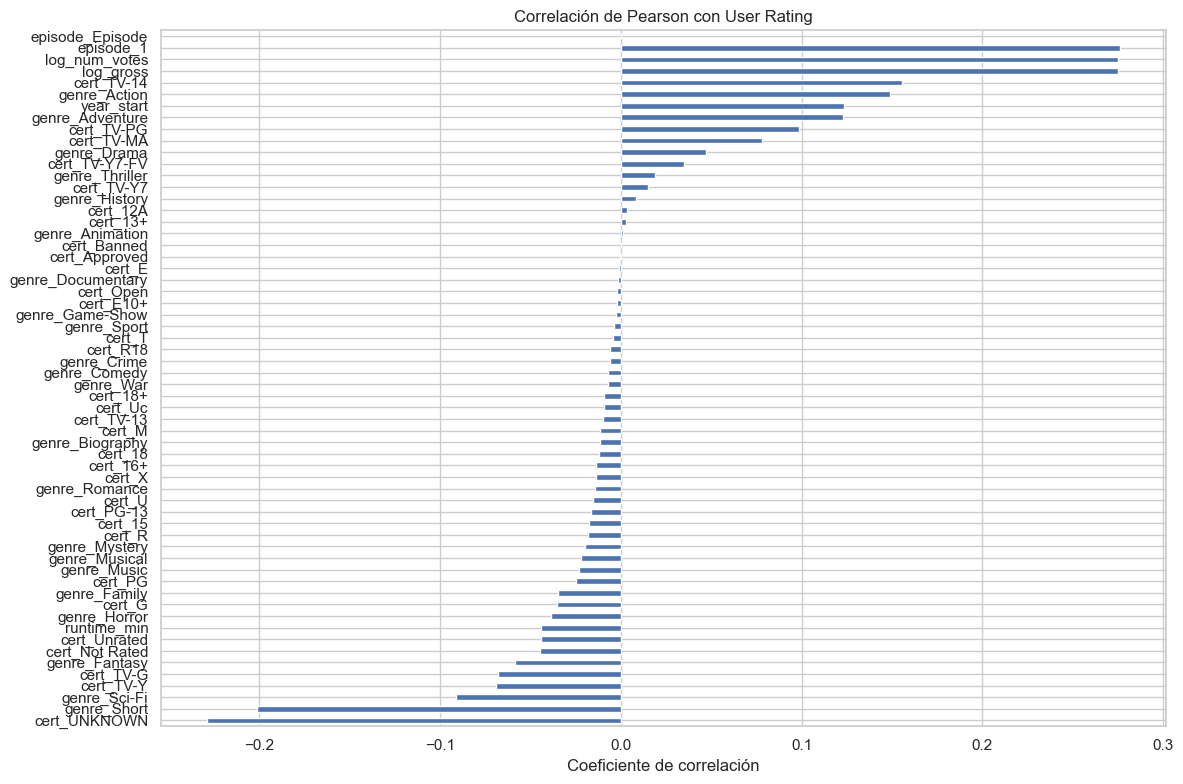

In [122]:
# CORRELACION CON VARIABLE OBJETIVO

corr_target = X.join(y).corr()["user_rating"].drop("user_rating")
corr_target.sort_values(ascending=False)

# Definición del umbral
selected_corr = corr_target[abs(corr_target) >= 0.05].index.tolist()
len(selected_corr), selected_corr

# Visualización 
plt.figure(figsize=(12, 8))
corr_target.sort_values().plot(kind="barh")
plt.title("Correlación de Pearson con User Rating")
plt.xlabel("Coeficiente de correlación")
plt.tight_layout()
plt.show()

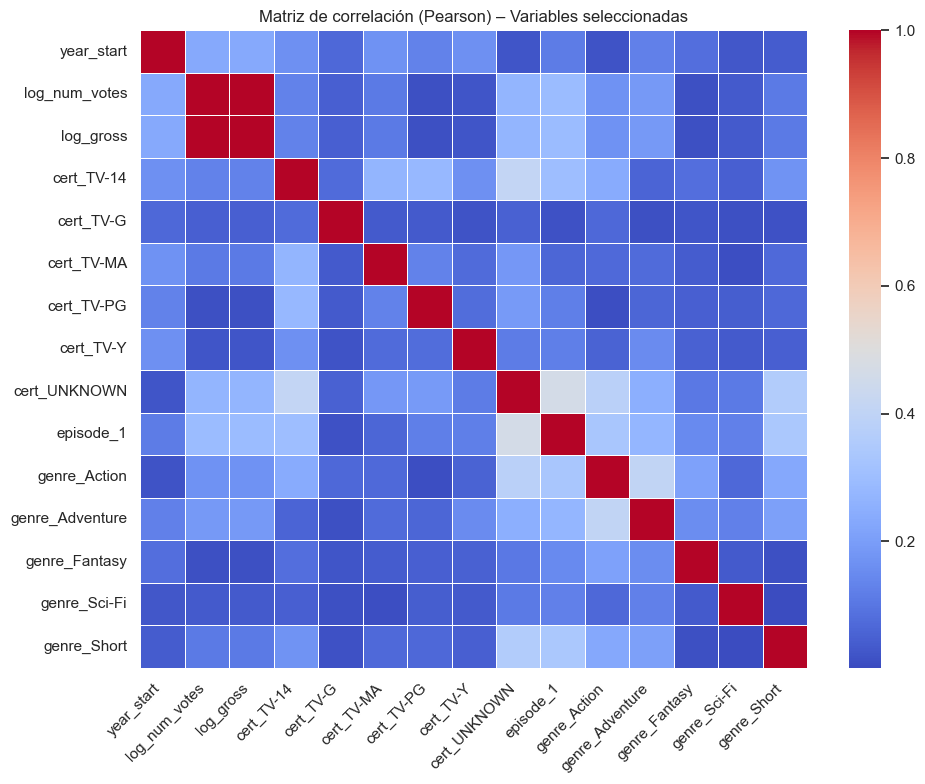

In [124]:
# ALTA CORRELACION (Multicolinealidad)

corr_matrix = X[selected_corr].corr().abs()
corr_mayor = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
to_drop = [col for col in corr_mayor.columns if any(corr_mayor[col] > 0.9)]
to_drop

# Visualización

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)
plt.title("Matriz de correlación (Pearson) – Variables seleccionadas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [126]:
selected_corr_final = [c for c in selected_corr if c not in to_drop]
len(selected_corr_final)

14

#### b. Filtro basado en Forward Selection

In [129]:
# Para usar las librerias usadas en clases, debemos hacer una versión categórica la variable objetivo (ya que es continua)
# Clasificación binaria por mediana: 1= rating alto (>= mediana), 0= rating bajo (< mediana)

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Definir X e y

X = df_final.drop(columns="user_rating")
y_reg = df_final["user_rating"]

# Convertir user_rating a clases (para poder usar clasificadores)

threshold = y_reg.median()
y = (y_reg >= threshold).astype(int)

y.value_counts(normalize=True)

user_rating
1    0.520713
0    0.479287
Name: proportion, dtype: float64

In [131]:
# Forward Selection con Logistic Regression

log_reg = LogisticRegression(max_iter=2000, solver="liblinear")

pipe_lr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("sfs", SequentialFeatureSelector(
        log_reg,
        n_features_to_select=15,      # ajusta: 10, 15, 20
        direction="forward",
        scoring="accuracy",
        cv=5,
        n_jobs=-1
    )),
    ("model", log_reg)
])

pipe_lr.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('sfs',
                 SequentialFeatureSelector(estimator=LogisticRegression(max_iter=2000,
                                                                        solver='liblinear'),
                                           n_features_to_select=15, n_jobs=-1,
                                           scoring='accuracy')),
                ('model',
                 LogisticRegression(max_iter=2000, solver='liblinear'))])

In [133]:
sfs_lr = pipe_lr.named_steps["sfs"]
selected_lr = X.columns[sfs_lr.get_support()].tolist()

len(selected_lr), selected_lr

(15,
 ['runtime_min',
  'log_num_votes',
  'log_gross',
  'cert_12A',
  'cert_13+',
  'cert_G',
  'cert_PG',
  'cert_TV-14',
  'cert_TV-G',
  'cert_TV-Y',
  'cert_TV-Y7-FV',
  'episode_1',
  'genre_Crime',
  'genre_History',
  'genre_Horror'])

In [135]:
# Forward Selection con KNN Classifier

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)

pipe_knn = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("sfs", SequentialFeatureSelector(
        knn,
        n_features_to_select=15,
        direction="forward",
        scoring="accuracy",
        cv=5,
        n_jobs=-1
    )),
    ("model", knn)
])

pipe_knn.fit(X, y)

sfs_knn = pipe_knn.named_steps["sfs"]
selected_knn = X.columns[sfs_knn.get_support()].tolist()

len(selected_knn), selected_knn

(15,
 ['runtime_min',
  'cert_Approved',
  'cert_E10+',
  'cert_Open',
  'cert_R',
  'cert_TV-PG',
  'cert_TV-Y',
  'cert_TV-Y7',
  'cert_UNKNOWN',
  'episode_Episode',
  'genre_Adventure',
  'genre_Drama',
  'genre_Fantasy',
  'genre_History',
  'genre_Sci-Fi'])

In [137]:
# Comparación de resultados

set_lr = set(selected_lr)
set_knn = set(selected_knn)

common = sorted(list(set_lr & set_knn))
only_lr = sorted(list(set_lr - set_knn))
only_knn = sorted(list(set_knn - set_lr))

print("Comunes:", len(common))
print("Solo LR:", len(only_lr))
print("Solo KNN:", len(only_knn))

common[:20]

Comunes: 3
Solo LR: 12
Solo KNN: 12


['cert_TV-Y', 'genre_History', 'runtime_min']

**Conclusiones:** 

- Estas 3 variables fueron seleccionadas por ambos modelo: 'cert_TV-Y', 'genre_History', 'runtime_min'
- 'runtime_min': la duración del anime influye en percepción de calidad
- 'cert_TV-Y': clasificación orientada a público infantil
- 'genre_History': género específico, menos frecuente pero con patrón distintivo
- Estas variables coinciden con lo obtenido en el EDA.